<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab1m/blob/main/ball_rolling_with_slipping/Lab1m_ball_on_slope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1m. Ball on a slope. Is it sliding or rolling?

Evgeny Kolonsky 2026

v. 0.1.0 - initial model

v. 0.1.1 - section 4 fixed ($M = F r$). Section 6 added.

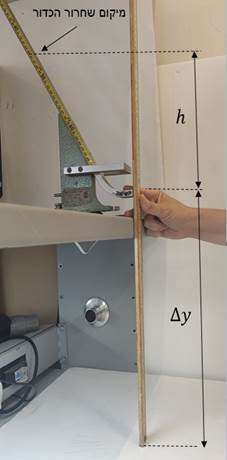

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. The trivial model: ball as a material point, no friction

The final velocity can be found from energy conservation law, having potentail energy $\Pi = m g h$ fully converted to kinetic energy of linear motion $K=\frac{mv^2}{2}$
$$
mgh = \frac{m v^2}{2}
\tag{1}
$$

The velocity in this model is overestimated. We should take into account that part of potental energy is lost on friction, and part of the kinetic energy is conserved in angular rotation.

# 2. Kinematics

The ball of radius $R$ is slipping or rolling along U-shaped gutter having width $2l$ and slope $\alpha$. We define effective radius of rolling
$$
r = \sqrt{R^2 - l^2} = R \cos\beta,
\tag{2.0}
$$
here angle $\beta$ shown on the ball cross-section figure as angle between contact point, center point and symmetry axis.

Rolling condition
$$
\omega = \frac{v}{r}
\tag{2.1}
$$
Slipping condition
$$
\omega < \frac{v}{r}.
\tag{2.2}
$$
Here $\omega$ is ball angular velocity, $v$ is ball linear velocity


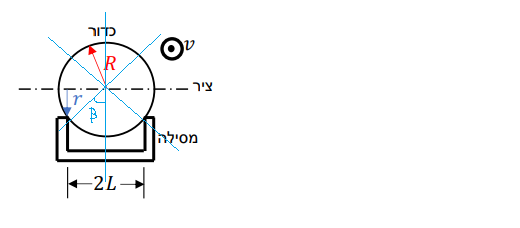

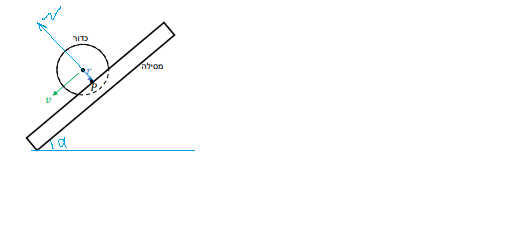

# 3. Ball rolling without slipping

From energy conservation law
$$
mgh = \frac{mv^2}{2} + \frac{I\omega^2}{2}
\tag{3.1}
$$
were inertia momentum  for ball is
$$
I = \frac{2}{5} m R^2.
\tag{3.2}
$$

Suggesting that rolling condition (2.1) is satisfied we receive
$$
mgh =
 \frac{m v^2}{2}  + \frac{\frac{2}{5} m R^2}{2}  
 \frac{v^2}{r^2}
 = \frac{1}{2} mv^2 \left( 1+ \frac{2}{5}\frac{R^2}{r^2} \right).
\tag{3.3}
$$
Here we have less optimistic estimation for final velocity than the trivial estimation (1), since part of the potential energy is stored in rotational motion.


# 4. Ball slipping

## Reaction and friction forces

Reaction forces $N_1, N_2$ are applied on two contact points and directed to the center of the ball with angle $\beta$ to the normal axis.

Total reaction force  in projection to normal axis is:
$$
N =  m g \cos \alpha.
\tag{4.1}
$$
On the other hand, total reaction force $N$ is the sum of two reaction forces, applied in contact points. In projection to noraml axis
$$
N = (N_1 + N_2) \cos\beta
\tag{4.2}
$$
The friction force is
$$
F = \mu (N_1 + N_2)
\tag{4.3}
$$
were $\mu$ is friction constant.

Therefore, combining (4.1), (4.2), (4.3) and (2.0) we can express the friction force on form
$$
F  = \mu \frac{N}{\cos\beta}  = \mu m g \cos\alpha\frac{R}{r}
\tag{4.4}
$$

Now suggesting that the ball is initially at rest, we can write dynamic equations for linear and angular velocities.

## Linear acceleration and velocity

Linear **acceleration $a$** of the center mass is defined by  gravity and friction forces:
$$
a = g \sin\alpha - \mu g \cos\alpha \frac{R}{r}
\tag{4.5}
$$

**Linear velocity** of center mass down the slope:
$$
v(t) = a t = \left(g \sin\alpha - \mu g \cos\alpha \frac{R}{r}\right) \cdot t
\tag{4.6}
$$

## Angular acceleration and velocity

**Angular acceleration** is defined by friction force momentum:
$$
M = F \cdot r
\tag{4.7}
$$

**Angular velocity** of the ball is therefore
$$
\omega(t) = \frac{M}{I} \cdot t = \frac{F r}{\frac{2}{5}mR^2} \cdot t =
\left( \frac{5}{2}\frac{\mu g \cos\alpha}{R} \right) \cdot t
\tag{4.8}
$$

## Slipping condition

Substituting expressions for linear and angular velocities  (4.6), (4.8)  to slipping condition (2.2), we can rewrite it in form
$$
\frac{5}{2} \frac{\mu \cos\alpha}{R} r < \sin\alpha - \mu\cos\alpha\frac{R}{r}
$$
or in the simplified form
$$
\mu < \frac{\tan\alpha}{\frac{5}{2}\frac{r}{R} +\frac{R}{r}}
\tag{4.7}
$$

# 5. Numeric example

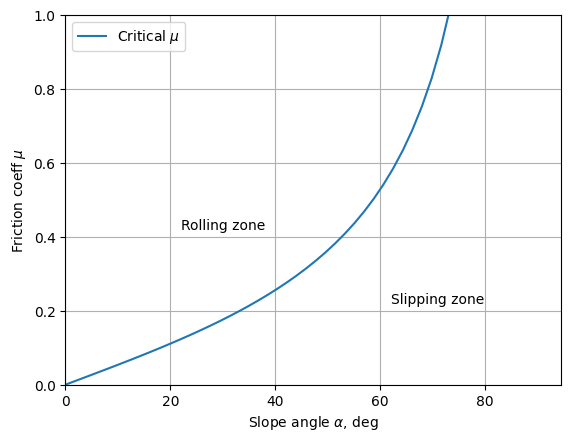

In [ ]:
R = 25e-3 / 2
L = 14e-3 / 2
r = np.sqrt(R**2 - L**2)

alpha = np.linspace(0, np.pi / 2)


critical = np.tan(alpha) / (2.5 * r / R + R / r)

plt.plot(alpha * 180 / np.pi, critical, label=r'Critical $\mu$')
plt.xlabel(r'Slope angle $\alpha$, deg')
plt.ylabel(r'Friction coeff $\mu$')
plt.annotate('Rolling zone', (22, 0.42))
plt.annotate('Slipping zone', (62, 0.22))
plt.ylim(0,1)
plt.xlim(left=0)
plt.legend()
plt.grid()




#6. Final velocities

Let's compare now expected velocities at the end of the slope for the case of rolling and case of slipping relative to the free fall velocity.

1. Free fall from height $h$, using equation (1):
$$
v = \sqrt{2 g h}
\tag{6.1}
$$

2. In case of rolling, by equation (3.3)
$$
v = \frac{\sqrt{2gh}}{ 1+ \frac{2}{5}\frac{R^2}{r^2}}
\tag{6.2}
$$

3. In case of slipping. The length of the slope $L$ is
$$
L = h / \sin\alpha
$$
Velocity at the end of the slope
$$
v = \sqrt{2 a L}.
$$
Substitution here expression slope length $L$ and for accelration (4.5), we have
$$
v = \sqrt{2gh \frac{\sin\alpha - \mu\cos\alpha \frac{R}{r}}{\sin\alpha}} =  \sqrt{
  2gh\left( 1 -  \frac{\mu}{\tan \alpha} \frac{R}{r}\right)}
\tag{6.3}
$$


## Final velocity on the graph

/tmp/ipython-input-1668/4185760651.py:10: RuntimeWarning: divide by zero encountered in divide
  v3 =  np.sqrt(1  - mu  * R / r   /  np.tan(alpha) )
/tmp/ipython-input-1668/4185760651.py:10: RuntimeWarning: invalid value encountered in sqrt
  v3 =  np.sqrt(1  - mu  * R / r   /  np.tan(alpha) )


Text(0, 0.5, 'Final velocity $\\frac{v }{\\sqrt{2gh}}$')

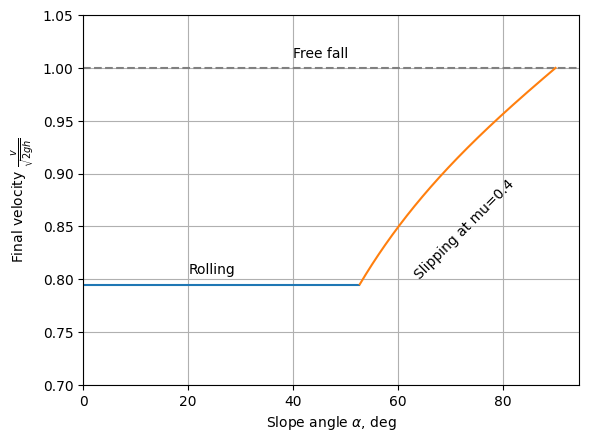

In [ ]:
mu = 0.4
R = 25e-3 / 2
L = 14e-3 / 2
r = np.sqrt(R**2 - L**2)

alpha = np.linspace(0, np.pi / 2, 1000)

v2 = np.sqrt(1 / (1+ 2 / 5 * R**2  / r**2) * np.ones_like(alpha))

v3 =  np.sqrt(1  - mu  * R / r   /  np.tan(alpha) )

alpha_critical = np.arctan(mu * (2.5 * r / R + R / r))
rolling = alpha <= alpha_critical
slipping = alpha >= alpha_critical

plt.axhline(1, color='gray', ls='--')
plt.annotate('Free fall', (40, 1.01))
plt.annotate(f'Slipping at mu={mu}', (alpha_critical * 180 / np.pi+10, 0.8), rotation=45)
plt.plot(alpha[rolling] * 180 / np.pi, v2[rolling])
plt.annotate('Rolling', (20, v2[0]+0.01))
plt.plot(alpha[slipping] * 180 / np.pi, v3[slipping])
plt.ylim(0.7, 1.05)
plt.xlim(left=0)
plt.grid()
plt.xlabel(r'Slope angle $\alpha$, deg')
plt.ylabel(r'Final velocity $\frac{v }{\sqrt{2gh}}$')

**Conclusion** We can expect, if the model is correct, that gradually increasing the slope and measuring  the final velocity we will see constant final velocity up to the critical point, depending on $\mu$ and $\alpha$. at this point slipping replaces rolling, and final velocity further increases with the angle up to the value of free fall velocity.